In [30]:
import pandas as pd
"""
This script merges the training and testing datasets into a single CSV file.
"""
df=pd.concat([pd.read_csv('train.csv'), pd.read_csv('test.csv')], ignore_index=True)
df.to_csv('merged_data.csv', index=False)

In [31]:
"""This script checks for missing values in the merged dataset."""
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

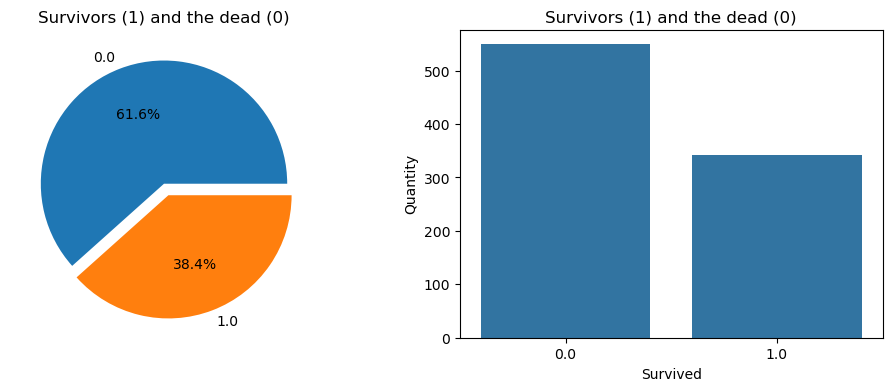

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
df['Survived'].value_counts().plot.pie( 
	explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False) 
ax[0].set_title('Survivors (1) and the dead (0)') 
ax[0].set_ylabel('') 
sns.countplot(x='Survived', data=df, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Survivors (1) and the dead (0)') 
plt.show()


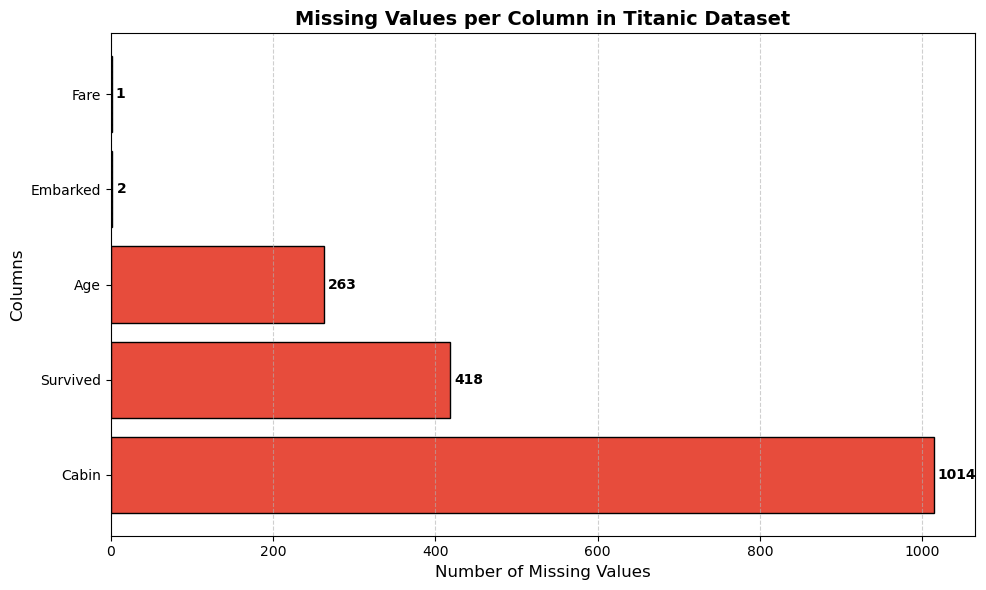

In [33]:
# Missing Values Visualization

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(missing.index, missing.values, color='#e74c3c', edgecolor='black')

# Add value labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2, 
             f'{int(width)}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Number of Missing Values', fontsize=12)
plt.ylabel('Columns', fontsize=12)
plt.title('Missing Values per Column in Titanic Dataset', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

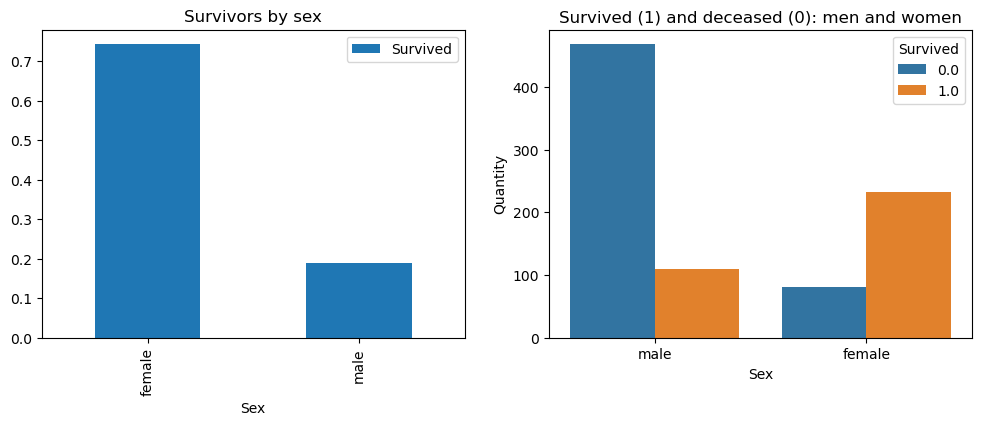

In [34]:
# Let us first visualize the number of sex counts
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
df[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0]) 
ax[0].set_title('Survivors by sex') 
sns.countplot(x='Sex', hue='Survived', data=df, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Survived (1) and deceased (0): men and women') 
plt.show()



In [35]:
# Feature Engineering: Optimizing Data for Model Training
# Loading the training and testing datasets
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

# Removing columns like Cabin that offer limited predictive value.
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)
# We can also drop the Ticket feature since it's unlikely to yield any useful information.
train = train.drop(['Ticket'], axis=1)
test = test.drop(['Ticket'], axis=1)

In [36]:
"""There are missing values in the Embarked feature. For that, we will replace the NULL values with 'S' as the number of Embarks for 'S' are higher than the other two."""
train = train.fillna({"Embarked": "S"})

# sort the ages into logical categories
import numpy as np
train["Age"] = train["Age"].fillna(-0.5)
test["Age"] = test["Age"].fillna(-0.5)
bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
          'Student', 'Young Adult', 'Adult', 'Senior']
train['AgeGroup'] = pd.cut(train["Age"], bins, labels=labels)
test['AgeGroup'] = pd.cut(test["Age"], bins, labels=labels)

In the 'title' column for both the test and train set, we will categorize them into an equal number of classes. Then we will assign numerical values to the title for convenience of model training.

In [37]:
# create a combined group of both datasets
combine = [train, test]

# extract a title for each Name in the 
# train and test datasets
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(train['Title'], train['Sex'])

# replace various titles with more common names
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
                                                 'Don', 'Dr', 'Major',
                                                 'Rev', 'Jonkheer', 'Dona'],
                                                'Rare')

    dataset['Title'] = dataset['Title'].replace(
        ['Countess', 'Lady', 'Sir'], 'Royal')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

# map each of the title groups to a numerical value
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
                 "Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

C:\Users\HP\AppData\Local\Temp\ipykernel_23524\4188457261.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train[['AgeGroup', 'Title']].groupby(['AgeGroup'], as_index=False).count())
C:\Users\HP\AppData\Local\Temp\ipykernel_23524\4188457261.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(test[['AgeGroup', 'Title']].groupby(['AgeGroup'], as_index=False).count())


      AgeGroup  Title
0      Unknown      0
1         Baby     48
2        Child     25
3     Teenager     70
4      Student    174
5  Young Adult    339
6        Adult    213
7       Senior     22
      AgeGroup  Title
0      Unknown      0
1         Baby     16
2        Child     13
3     Teenager     29
4      Student     92
5  Young Adult    153
6        Adult    104
7       Senior     11


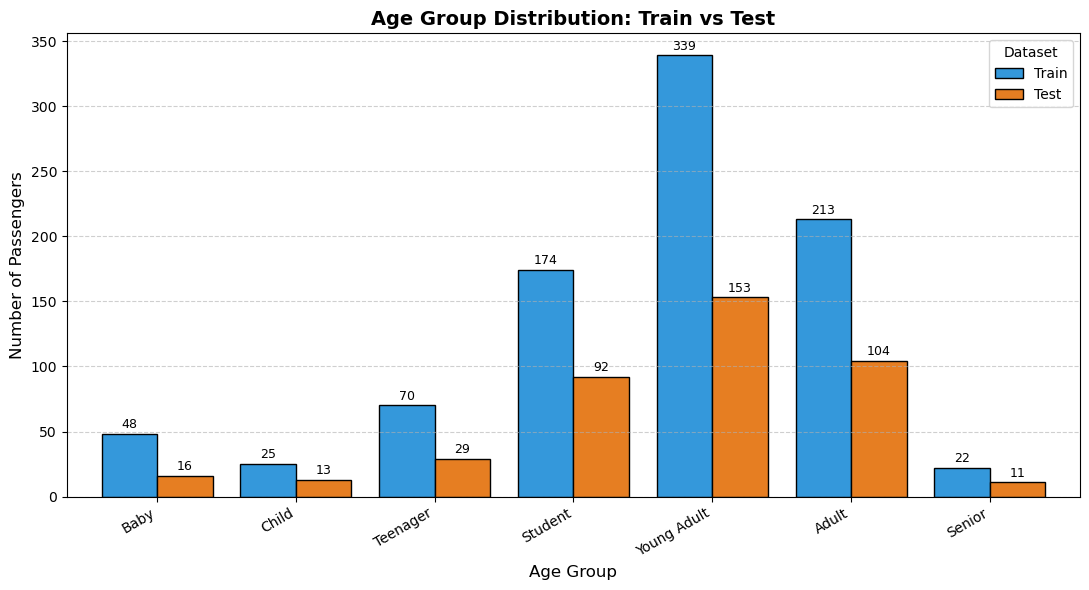

In [38]:
# Now using the title information we can fill in the missing age values.
age_title_mapping = {1: "Young Adult", 2: "Student",
                     3: "Adult", 4: "Baby", 5: "Adult", 6: "Adult"}

# --- Train ---
mask = train["AgeGroup"] == "Unknown"
train.loc[mask, "AgeGroup"] = train.loc[mask, "Title"].map(age_title_mapping)

# --- Test ---
mask = test["AgeGroup"] == "Unknown"
test.loc[mask, "AgeGroup"] = test.loc[mask, "Title"].map(age_title_mapping)

print(train[['AgeGroup', 'Title']].groupby(['AgeGroup'], as_index=False).count())
print(test[['AgeGroup', 'Title']].groupby(['AgeGroup'], as_index=False).count())

# Build a comparison DataFrame
train_counts = train["AgeGroup"].value_counts().sort_index()
test_counts  = test["AgeGroup"].value_counts().sort_index()

age_order = ["Baby", "Child", "Teenager", "Student",
             "Young Adult", "Adult", "Senior"]

compare = pd.DataFrame({
    "Train": train_counts.reindex(age_order, fill_value=0),
    "Test":  test_counts.reindex(age_order, fill_value=0),
})

ax = compare.plot(kind="bar", figsize=(11, 6),
                  color=["#3498db", "#e67e22"],
                  edgecolor="black", width=0.8)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=2)

plt.title("Age Group Distribution: Train vs Test", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [39]:
# map each Age value to a numerical value
age_mapping = {'Baby': 1, 'Child': 2, 'Teenager': 3,
               'Student': 4, 'Young Adult': 5, 'Adult': 6, 
               'Senior': 7}
train['AgeGroup'] = train['AgeGroup'].map(age_mapping)
test['AgeGroup'] = test['AgeGroup'].map(age_mapping)

train.head()

# dropping the Age feature for now, might change
train = train.drop(['Age'], axis=1)
test = test.drop(['Age'], axis=1)

# Drop the name feature since it contains no more useful information.
train = train.drop(['Name'], axis=1)
test = test.drop(['Name'], axis=1)

In [40]:
# Assign numerical values to sex and embarks categories
sex_mapping = {"male": 0, "female": 1}
train['Sex'] = train['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

embarked_mapping = {"S": 1, "C": 2, "Q": 3}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)

In [ ]:
# Fill in the missing Fare value in the test set based on the mean fare for that P-class

# Impute missing Fare using the median/mean of the same Pclass 
# Compute mean Fare per Pclass from train (only once, not per-row)
pclass_fare_mean = train.groupby("Pclass")["Fare"].mean().round(4)

# Find rows in test where Fare is missing
mask = test["Fare"].isnull()
# Fill using the Pclass → Fare mean mapping
test.loc[mask, "Fare"] = test.loc[mask, "Pclass"].map(pclass_fare_mean)


,PassengerId,Pclass,Sex,SibSp,Parch,Fare,Embarked,AgeGroup,Title
0,892,3,0,0,0,7.8292,3,5.0,1
1,893,3,1,1,0,7.0000,1,6.0,3
2,894,2,0,0,0,9.6875,3,7.0,1
3,895,3,0,0,0,8.6625,1,5.0,1
4,896,3,1,1,1,12.2875,1,4.0,3


Model Training: Building the Predictive Model
In this phase, we employ Random Forest as our algorithm to train the model for predicting survival

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the Survived and PassengerId
# column from the trainset
predictors = train.drop(['Survived', 'PassengerId'], axis=1)
target = train["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
    predictors, target, test_size=0.2, random_state=0)


(891, 10)

In [49]:
"""Now import the random forest function from the ensemble module of sklearn and for the training set."""
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest = RandomForestClassifier()

# Fit the training data along with its output
randomforest.fit(x_train, y_train)
y_pred = randomforest.predict(x_val)

# Find the accuracy score of the model
acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(acc_randomforest)

84.36


In [ ]:
from sklearn.model_selection import (
    cross_val_score, learning_curve, validation_curve,
    StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Confirm your variables exist
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val  :", x_val.shape)
print("y_val  :", y_val.shape)

# Basic Accuracy + Classification Report
y_pred = randomforest.predict(x_val)

print("Accuracy :", round(accuracy_score(y_val, y_pred) * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_score(y_val, randomforest.predict_proba(x_val)[:, 1]), 4))
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Not Survived", "Survived"]))


x_train: (712, 8)
y_train: (712,)
x_val  : (179, 8)
y_val  : (179,)
Accuracy : 84.36 %
ROC-AUC  : 0.883

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.86      0.89      0.88       110
    Survived       0.82      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



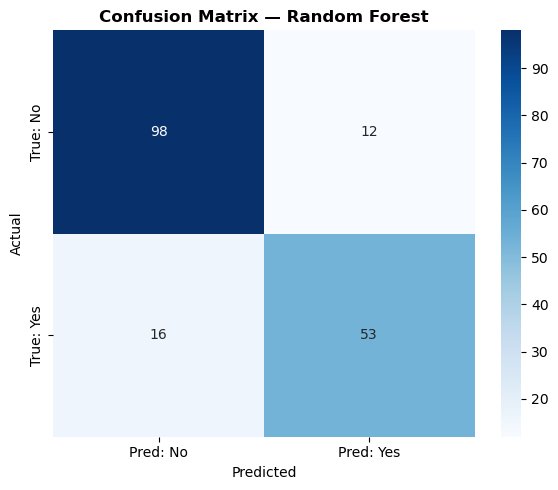

'\ninterpretation:\n\nTop-right = False Positives (predicted survived, actually died)\n\nBottom-left = False Negatives (predicted died, actually survived) ← usually the bigger weakness\n\n'

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["True: No", "True: Yes"])
plt.title("Confusion Matrix — Random Forest", fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()
"""
interpretation:

Top-right = False Positives (predicted survived, actually died)

Bottom-left = False Negatives (predicted died, actually survived) ← usually the bigger weakness

"""

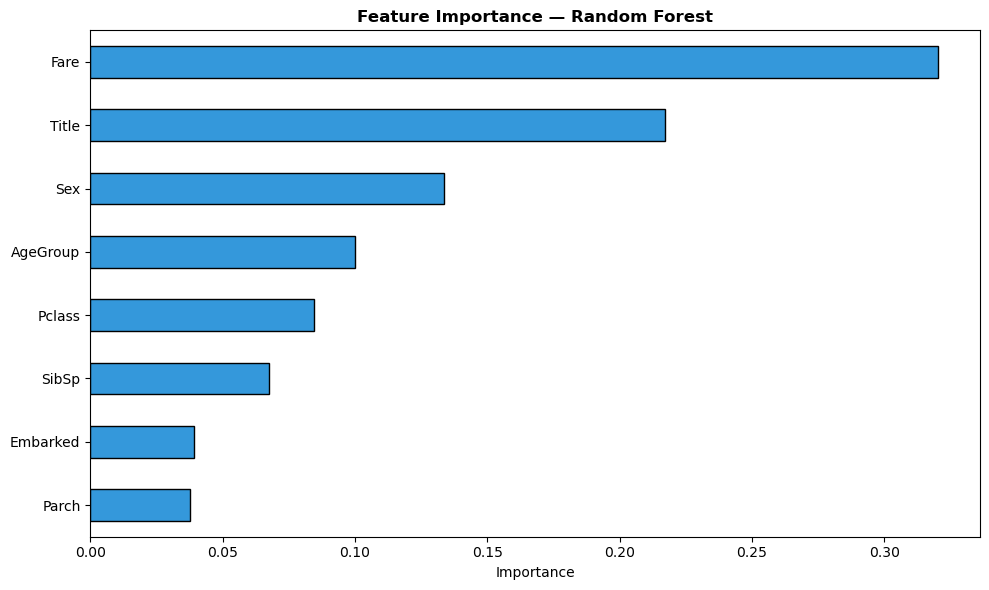

Fare        0.320146
Title       0.217201
Sex         0.133639
AgeGroup    0.100140
Pclass      0.084376
SibSp       0.067524
Embarked    0.039227
Parch       0.037747
dtype: float64


In [52]:
# Feature Importance
importances = pd.Series(
    randomforest.feature_importances_,
    index=x_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="#3498db", edgecolor="black")
plt.title("Feature Importance — Random Forest", fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Print top 10
print(importances.sort_values(ascending=False).head(10))

In [55]:
# Consolidated Summary Report
def rf_diagnostics(model, x_train, y_train, x_val, y_val):
    train_pred = model.predict(x_train)
    val_pred   = model.predict(x_val)
    val_proba  = model.predict_proba(x_val)[:, 1]

    train_acc = accuracy_score(y_train, train_pred)
    val_acc   = accuracy_score(y_val, val_pred)
    auc       = roc_auc_score(y_val, val_proba)

    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")

    print("=" * 55)
    print("      RANDOM FOREST REPORT")
    print("=" * 55)
    print(f"Train Accuracy      : {train_acc:.4f}")
    print(f"Val   Accuracy      : {val_acc:.4f}")
    print(f"Accuracy Gap        : {train_acc - val_acc:.4f}")
    print(f"ROC-AUC             : {auc:.4f}")
    print("-" * 55)
    print(f"CV Mean Accuracy    : {cv_scores.mean():.4f}")
    print(f"CV Std Deviation    : {cv_scores.std():.4f}")
    print(f"CV Variance         : {cv_scores.var():.6f}")
    print(f"CV Min / Max        : {cv_scores.min():.4f} / {cv_scores.max():.4f}")
    print("-" * 55)

    if train_acc - val_acc > 0.10:
        print("Verdict: OVERFITTING")
    elif train_acc < 0.70 and val_acc < 0.70:
        print("Verdict: UNDERFITTING")
    elif cv_scores.std() > 0.05:
        print("Verdict: HIGH VARIANCE")
    else:
        print("Verdict: WELL-FITTED")

    print("=" * 55)
    print("Classification Report:")
    print(classification_report(y_val, val_pred,
                                target_names=["Not Survived", "Survived"]))

rf_diagnostics(randomforest, x_train, y_train, x_val, y_val)

      RANDOM FOREST REPORT
Train Accuracy      : 0.9551
Val   Accuracy      : 0.8436
Accuracy Gap        : 0.1115
ROC-AUC             : 0.8830
-------------------------------------------------------
CV Mean Accuracy    : 0.7963
CV Std Deviation    : 0.0314
CV Variance         : 0.000987
CV Min / Max        : 0.7606 / 0.8531
-------------------------------------------------------
Verdict: OVERFITTING
Classification Report:
              precision    recall  f1-score   support

Not Survived       0.86      0.89      0.88       110
    Survived       0.82      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

